*NDTA 631 Data Analysis and Visualisation | Group Assignment 2026*

### South Africa Economic Structure and External Orientation: A 1960–2025 Data Analysis

### Group Members
- Matshidiso Mohatla - 202338641
- Tlotliso Ledwaba   - 202428830
- Thabo Machume      - 202204405
- Chantele Mucuio    - 202331627 
- Mercy Mothata      - 202419335

### Dataset Sources:
1. **Exports of goods and services (% of GDP)**
2. **Services, value added (% of GDP)**

The central question is:

How has South Africa's services-oriented domestic economic structure compared with its external export orientation from 1960 to 2025, and what does the long-run pattern reveal about changes in the relative importance and stability of the two indicators?

## Analysis roadmap

The notebook first establishes that the two datasets are comparable, then measures their long-run behaviour, visualises the changes over time, integrates the cleaned data into SQLite, and finally produces an Excel workbook containing transformed data, conditional formatting, charts, and a summary of the findings.

In [1]:
# Core libraries and reproducibility settings
import os
import sqlite3
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("south_africa_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Analysis environment ready.")

Analysis environment ready.


# Q1. Data Preparation 

## 1.1 Load the exports dataset

The first loading stage focuses only on the exports dataset.

In [2]:
EXPORT_CANDIDATES = [
    "exports_of_goods_and_services.csv",
    "WB_WDI_NE_EXP_GNFS_ZS.csv",
    "Exports of Goods and Services (WB_WDI_NE_EXP_GNFS_ZS).csv"
]

exports_file = next((f for f in EXPORT_CANDIDATES if Path(f).exists()), None)
if exports_file is None:
    raise FileNotFoundError(
        "Exports dataset not found. Place the World Bank exports CSV in the notebook folder. "
        f"Expected one of: {EXPORT_CANDIDATES}"
    )

gas_data = pd.read_csv(exports_file)

print(f"Exports dataset loaded: {exports_file}")
print(f"Raw shape: {gas_data.shape[0]:,} rows x {gas_data.shape[1]} columns")
display(gas_data.head())

Exports dataset loaded: exports_of_goods_and_services.csv
Raw shape: 11,390 rows x 41 columns


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,OBS_VALUE,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,UNIT_MULT,OBS_STATUS,OBS_CONF,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,37.14,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Zambia,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,19.16,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Zimbabwe,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFE,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2016,23.68,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Africa Eastern and Southern,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ARB,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2016,37.34,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Arab World,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,CEB,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2016,62.21,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Central Europe and the Baltics,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


## 1.2 Load the services value-added dataset

The second loading stage brings in the services dataset. 

In [3]:
SERVICES_CANDIDATES = [
    "services_,_value_addes.csv",
    "NVSRVTOTL.csv",
    "services_value_added.csv"
]

services_file = next((f for f in SERVICES_CANDIDATES if Path(f).exists()), None)
if services_file is None:
    raise FileNotFoundError(
        "Services dataset not found. Place the World Bank services CSV in the notebook folder. "
        f"Expected one of: {SERVICES_CANDIDATES}"
    )

sva_data = pd.read_csv(services_file)

print(f"Services dataset loaded: {services_file}")
print(f"Raw shape: {sva_data.shape[0]:,} rows x {sva_data.shape[1]} columns")
display(sva_data.head())

Services dataset loaded: services_,_value_addes.csv
Raw shape: 10,765 rows x 41 columns


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,OBS_VALUE,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,UNIT_MULT,OBS_STATUS,OBS_CONF,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,41.93,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,"Yemen, Rep.","Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,56.22,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Zambia,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,58.65,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Zimbabwe,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2016,54.03,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Africa Eastern and Southern,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFW,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2016,54.16,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Africa Western and Central,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


## 1.3 Selecting the analysis fields and establishing comparability

The raw World Bank extracts contain extensive metadata. Only fields needed to identify the country, indicator, year, observation, and measurement are retained. This reduces noise while preserving enough metadata to validate that the two datasets measure compatible concepts.

In [4]:
analysis_columns = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE",
    "UNIT_MEASURE_LABEL",
    "UNIT_TYPE_LABEL"
]

missing_export_columns = [c for c in analysis_columns if c not in gas_data.columns]
missing_services_columns = [c for c in analysis_columns if c not in sva_data.columns]

if missing_export_columns or missing_services_columns:
    raise ValueError(
        f"Missing required columns. Exports: {missing_export_columns}; Services: {missing_services_columns}"
    )

# Filtering the exports dataset to South Africa and the exact required indicator/unit.
exports_sa = gas_data[
    (gas_data["REF_AREA"] == "ZAF") &
    (gas_data["UNIT_MEASURE_LABEL"].astype(str).str.strip() == "Percentage of GDP")
].copy()

exports_sa = exports_sa[
    exports_sa["INDICATOR_LABEL"].astype(str).str.contains(
        "Exports of goods and services", case=False, na=False
    )
].copy()

# Filtering the services dataset to South Africa and the same unit concept.
services_sa = sva_data[
    (sva_data["REF_AREA"] == "ZAF") &
    (sva_data["UNIT_MEASURE_LABEL"].astype(str).str.strip() == "Percentage of GDP")
].copy()

services_sa = services_sa[
    services_sa["INDICATOR_LABEL"].astype(str).str.contains(
        "Services,? value added", case=False, regex=True, na=False
    )
].copy()

exports_analysis = exports_sa[analysis_columns].copy()
services_analysis = services_sa[analysis_columns].copy()

print("South Africa records after indicator/unit filtering:")
print(f"Exports: {len(exports_analysis)}")
print(f"Services value added: {len(services_analysis)}")

South Africa records after indicator/unit filtering:
Exports: 66
Services value added: 66


### Validation checkpoint: the two datasets must mean the same kind of thing

Both series must represent **annual South African values expressed as a percentage of GDP**.

In [5]:
indicator_check = pd.DataFrame({
    "Dataset": ["Exports of goods and services", "Services value added"],
    "Country": [exports_analysis["REF_AREA_LABEL"].iloc[0], services_analysis["REF_AREA_LABEL"].iloc[0]],
    "Indicator": [exports_analysis["INDICATOR_LABEL"].iloc[0], services_analysis["INDICATOR_LABEL"].iloc[0]],
    "Unit": [exports_analysis["UNIT_MEASURE_LABEL"].iloc[0], services_analysis["UNIT_MEASURE_LABEL"].iloc[0]],
})

display(indicator_check)

assert set(exports_analysis["UNIT_MEASURE_LABEL"]) == {"Percentage of GDP"}
assert set(services_analysis["UNIT_MEASURE_LABEL"]) == {"Percentage of GDP"}
print("Validation passed: both indicators are measured as Percentage of GDP.")

,Dataset,Country,Indicator,Unit
0,Exports of goods and services,South Africa,Exports of goods and services (% of GDP),Percentage of GDP
1,Services value added,South Africa,"Services, value added (% of GDP)",Percentage of GDP


Validation passed: both indicators are measured as Percentage of GDP.


## 1.4 Standardise, type-convert and clean

The year and observation fields are explicitly converted to numeric values. Invalid records are removed, the data are sorted chronologically, and duplicate South Africa-year records are checked before the two series are merged.

In [6]:
rename_columns = {
    "REF_AREA": "Country_Code",
    "REF_AREA_LABEL": "Country",
    "INDICATOR": "Indicator_Code",
    "INDICATOR_LABEL": "Indicator",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Value",
    "UNIT_MEASURE_LABEL": "Unit",
    "UNIT_TYPE_LABEL": "Unit_Type"
}

exports_analysis = exports_analysis.rename(columns=rename_columns).copy()
services_analysis = services_analysis.rename(columns=rename_columns).copy()

for df in [exports_analysis, services_analysis]:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df.dropna(subset=["Year", "Value"], inplace=True)
    df["Year"] = df["Year"].astype(int)
    df.sort_values("Year", inplace=True)
    df.reset_index(drop=True, inplace=True)

# Removing exact duplicate rows if present, then explicitly checking for duplicate country-year observations.
exports_analysis.drop_duplicates(inplace=True)
services_analysis.drop_duplicates(inplace=True)

print("Cleaned exports shape:", exports_analysis.shape)
print("Cleaned services shape:", services_analysis.shape)

Cleaned exports shape: (66, 8)
Cleaned services shape: (66, 8)


In [7]:
# Data-quality auditting
quality_summary = pd.DataFrame({
    "Dataset": ["Exports of goods and services", "Services value added"],
    "Rows": [len(exports_analysis), len(services_analysis)],
    "Columns": [exports_analysis.shape[1], services_analysis.shape[1]],
    "Missing Values": [exports_analysis["Value"].isna().sum(), services_analysis["Value"].isna().sum()],
    "Duplicate Country-Year Records": [
        exports_analysis.duplicated(["Country_Code", "Year"]).sum(),
        services_analysis.duplicated(["Country_Code", "Year"]).sum()
    ],
    "Minimum Year": [exports_analysis["Year"].min(), services_analysis["Year"].min()],
    "Maximum Year": [exports_analysis["Year"].max(), services_analysis["Year"].max()]
})

display(quality_summary)

assert quality_summary["Missing Values"].sum() == 0
assert quality_summary["Duplicate Country-Year Records"].sum() == 0
assert exports_analysis["Year"].min() == services_analysis["Year"].min()
assert exports_analysis["Year"].max() == services_analysis["Year"].max()
print("Data-quality checks passed.")

,Dataset,Rows,Columns,Missing Values,Duplicate Country-Year Records,Minimum Year,Maximum Year
0,Exports of goods and services,66,8,0,0,1960,2025
1,Services value added,66,8,0,0,1960,2025


Data-quality checks passed.


### Data Preparation Insight

The cleaned datasets provide a common 1960–2025 annual window, with one South African observation per year for each indicator. The strongest quality-control result is not simply that there are no missing values; it is that the **same year-by-year structure exists in both series**, allowing a valid inner join and direct comparison. The analysis therefore does not need to interpolate (insert) missing years or compare mismatched time windows.

In [8]:
def descriptive_table(df):
    return pd.Series({
        "Count": df["Value"].count(),
        "Mean": df["Value"].mean(),
        "Median": df["Value"].median(),
        "Standard Deviation": df["Value"].std(),
        "Minimum": df["Value"].min(),
        "25th Percentile": df["Value"].quantile(0.25),
        "75th Percentile": df["Value"].quantile(0.75),
        "Maximum": df["Value"].max(),
        "Range": df["Value"].max() - df["Value"].min(),
        "Coefficient of Variation (%)": (df["Value"].std() / df["Value"].mean()) * 100
    })

descriptive_stats = pd.DataFrame({
    "Exports (% GDP)": descriptive_table(exports_analysis),
    "Services Value Added (% GDP)": descriptive_table(services_analysis)
})

display(descriptive_stats.round(2))

,Exports (% GDP),Services Value Added (% GDP)
Count,66.00,66.00
Mean,25.15,57.48
Median,25.09,57.13
Standard Deviation,3.81,5.33
Minimum,18.40,46.89
25th Percentile,22.05,53.03
75th Percentile,27.67,62.74
Maximum,33.54,64.61
Range,15.14,17.72
Coefficient of Variation (%),15.14,9.26


In [9]:
# Locating historical extremes and the latest observation.
extreme_values = pd.DataFrame([
    ["Exports of goods and services", "Lowest", exports_analysis.loc[exports_analysis["Value"].idxmin(), "Year"], exports_analysis["Value"].min()],
    ["Exports of goods and services", "Highest", exports_analysis.loc[exports_analysis["Value"].idxmax(), "Year"], exports_analysis["Value"].max()],
    ["Services value added", "Lowest", services_analysis.loc[services_analysis["Value"].idxmin(), "Year"], services_analysis["Value"].min()],
    ["Services value added", "Highest", services_analysis.loc[services_analysis["Value"].idxmax(), "Year"], services_analysis["Value"].max()],
], columns=["Indicator", "Observation", "Year", "Value (% GDP)"])

display(extreme_values.round(2))

latest_year = min(exports_analysis["Year"].max(), services_analysis["Year"].max())
latest = pd.DataFrame({
    "Indicator": ["Exports of goods and services", "Services value added"],
    "Year": [latest_year, latest_year],
    "Value (% GDP)": [
        exports_analysis.loc[exports_analysis["Year"] == latest_year, "Value"].iloc[0],
        services_analysis.loc[services_analysis["Year"] == latest_year, "Value"].iloc[0]
    ]
})
display(latest.round(2))

,Indicator,Observation,Year,Value (% GDP)
0,Exports of goods and services,Lowest,1970,18.40
1,Exports of goods and services,Highest,2022,33.54
2,Services value added,Lowest,1980,46.89
3,Services value added,Highest,2020,64.61


,Indicator,Year,Value (% GDP)
0,Exports of goods and services,2025,31.41
1,Services value added,2025,63.07


### Descriptive Insight

The two indicators operate at very different typical levels: services value added has a substantially larger share of GDP than exports. However, the raw standard deviation should not be interpreted as evidence that services are more unstable, because the indicators have different scales. The coefficient of variation corrects for this scale difference and allows relative volatility to be compared fairly.

This distinction matters for the story: the services series can move more percentage points while exports can still be more volatile relative to their own normal level.

####

# Q2. NumPy / Numerical Analysis

The cleaned observations are now converted into NumPy arrays. The numerical analysis extends the descriptive statistics by performing array reshaping, element-wise operations, correlation and period comparisons.

In [10]:
# Creating aligned year-by-year arrays from the cleaned datasets.
comparison = pd.merge(
    exports_analysis[["Country_Code", "Country", "Year", "Value"]].rename(columns={"Value": "Exports_Pct_GDP"}),
    services_analysis[["Country_Code", "Country", "Year", "Value"]].rename(columns={"Value": "Services_Pct_GDP"}),
    on=["Country_Code", "Country", "Year"],
    how="inner"
).sort_values("Year").reset_index(drop=True)

# Converting cleaned values into NumPy arrays
exports_array = comparison["Exports_Pct_GDP"].to_numpy(dtype=float)
services_array = comparison["Services_Pct_GDP"].to_numpy(dtype=float)

a_years = comparison["Year"].to_numpy(dtype=int)

# Displaying basic array information
print("Exports array shape:", exports_array.shape)
print("Services array shape:", services_array.shape)
print("Aligned observations:", len(comparison))

Exports array shape: (66,)
Services array shape: (66,)
Aligned observations: 66


In [11]:
# Core NumPy calculations
numpy_results = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Standard Deviation", "Minimum", "Maximum", "Range"],
    "Exports (% GDP)": [
        np.mean(exports_array), np.median(exports_array), np.std(exports_array),
        np.min(exports_array), np.max(exports_array), np.ptp(exports_array)
    ],
    "Services Value Added (% GDP)": [
        np.mean(services_array), np.median(services_array), np.std(services_array),
        np.min(services_array), np.max(services_array), np.ptp(services_array)
    ]
})

display(numpy_results.round(2))

,Statistic,Exports (% GDP),Services Value Added (% GDP)
0,Mean,25.15,57.48
1,Median,25.09,57.13
2,Standard Deviation,3.78,5.28
3,Minimum,18.40,46.89
4,Maximum,33.54,64.61
5,Range,15.14,17.72


In [12]:
# Reshaping arrays and performing element-wise operations.
exports_reshaped = exports_array.reshape(-1, 1)
services_reshaped = services_array.reshape(-1, 1)

exports_deviation = exports_array - np.mean(exports_array)
services_deviation = services_array - np.mean(services_array)

# Year-by-year gap: positive values mean services value added is larger as a share of GDP.
services_minus_exports = services_array - exports_array

# Pearson correlation using NumPy. This measures co-movement, not causation.
correlation_matrix = np.corrcoef(exports_array, services_array)
correlation = correlation_matrix[0, 1]

print("Exports reshape:", exports_array.shape, "->", exports_reshaped.shape)
print("Services reshape:", services_array.shape, "->", services_reshaped.shape)
print("First five export deviations from mean:", np.round(exports_deviation[:5], 2))
print("First five services deviations from mean:", np.round(services_deviation[:5], 2))
print(f"Pearson correlation: {correlation:.3f}")

Exports reshape: (66,) -> (66, 1)
Services reshape: (66,) -> (66, 1)
First five export deviations from mean: [ 0.44  0.19  0.31 -0.31 -1.34]
First five services deviations from mean: [-3.32 -3.51 -3.35 -3.66 -3.64]
Pearson correlation: 0.301


In [13]:
# Period comparison: 1960s, 1970s, ..., 2020s.
comparison["Decade"] = (comparison["Year"] // 10) * 10

decade_summary = comparison.groupby("Decade").agg(
    Exports_Mean=("Exports_Pct_GDP", "mean"),
    Services_Mean=("Services_Pct_GDP", "mean"),
    Gap_Mean=("Services_Pct_GDP", lambda x: np.nan)
).reset_index()

# Calculating the decade gap correctly after aggregation.
decade_summary["Gap_Mean"] = decade_summary["Services_Mean"] - decade_summary["Exports_Mean"]

display(decade_summary.round(2))

,Decade,Exports_Mean,Services_Mean,Gap_Mean
0,1960,23.27,54.06,30.79
1,1970,23.79,53.22,29.43
2,1980,25.63,50.15,24.52
3,1990,20.76,57.74,36.99
4,2000,26.08,62.19,36.12
5,2010,27.59,64.19,36.60
6,2020,31.46,63.07,31.61


In [14]:
# Recent-period comparison and change from the first to last available year.
first_year = comparison["Year"].min()
last_year = comparison["Year"].max()
first_row = comparison.iloc[0]
last_row = comparison.iloc[-1]

change_summary = pd.DataFrame({
    "Indicator": ["Exports of goods and services", "Services value added"],
    "First Year": [first_year, first_year],
    "First Value": [first_row["Exports_Pct_GDP"], first_row["Services_Pct_GDP"]],
    "Last Year": [last_year, last_year],
    "Last Value": [last_row["Exports_Pct_GDP"], last_row["Services_Pct_GDP"]],
    "Change (percentage points)": [
        last_row["Exports_Pct_GDP"] - first_row["Exports_Pct_GDP"],
        last_row["Services_Pct_GDP"] - first_row["Services_Pct_GDP"]
    ]
})

display(change_summary.round(2))

,Indicator,First Year,First Value,Last Year,Last Value,Change (percentage points)
0,Exports of goods and services,1960,25.59,2025,31.41,5.82
1,Services value added,1960,54.17,2025,63.07,8.90


In [15]:
# Generating specific numerical findings.
exports_cv = np.std(exports_array, ddof=1) / np.mean(exports_array) * 100
services_cv = np.std(services_array, ddof=1) / np.mean(services_array) * 100

avg_gap = np.mean(services_minus_exports)
latest_gap = services_array[-1] - exports_array[-1]
max_gap_idx = np.argmax(services_minus_exports)
min_gap_idx = np.argmin(services_minus_exports)

print("NUMERICAL FINDINGS")
print(f"1. Services value added exceeds exports by {avg_gap:.2f} percentage points of GDP on average across the full period.")
print(f"2. In {a_years[-1]}, the services-minus-exports gap was {latest_gap:.2f} percentage points of GDP.")
print(f"3. The widest gap occurred in {a_years[max_gap_idx]} at {services_minus_exports[max_gap_idx]:.2f} percentage points.")
print(f"4. The narrowest gap occurred in {a_years[min_gap_idx]} at {services_minus_exports[min_gap_idx]:.2f} percentage points.")
print(f"5. Relative volatility is higher for {'exports' if exports_cv > services_cv else 'services value added'} based on the coefficient of variation ({max(exports_cv, services_cv):.2f}% vs {min(exports_cv, services_cv):.2f}%).")
print(f"6. Pearson correlation is {correlation:.3f}; this describes co-movement over time and should not be interpreted as causation.")

NUMERICAL FINDINGS
1. Services value added exceeds exports by 32.33 percentage points of GDP on average across the full period.
2. In 2025, the services-minus-exports gap was 31.66 percentage points of GDP.
3. The widest gap occurred in 2004 at 39.77 percentage points.
4. The narrowest gap occurred in 1980 at 15.02 percentage points.
5. Relative volatility is higher for exports based on the coefficient of variation (15.14% vs 9.26%).
6. Pearson correlation is 0.301; this describes co-movement over time and should not be interpreted as causation.


### NumPy Insight

The most useful numerical result is the services-minus-exports gap. Because both indicators use the same denominator (GDP), this gap provides a direct measure of how much larger the services value-added share is than the export share in a given year. Tracking the gap across decades turns two separate time series into a more interpretable structural comparison: a widening gap means services value added is pulling further away from exports as a share of GDP, while a narrowing gap means the two indicators are becoming more similar.

####

# Q3. Visualisation

The visualisations are designed to answer different questions rather than repeat the same chart. The line chart establishes the long-run trajectory, the gap chart shows where the relationship widens or narrows, the distribution plots show how typical observations are spread, the decade chart highlights structural shifts, and the scatter plot tests the strength of the time trend.

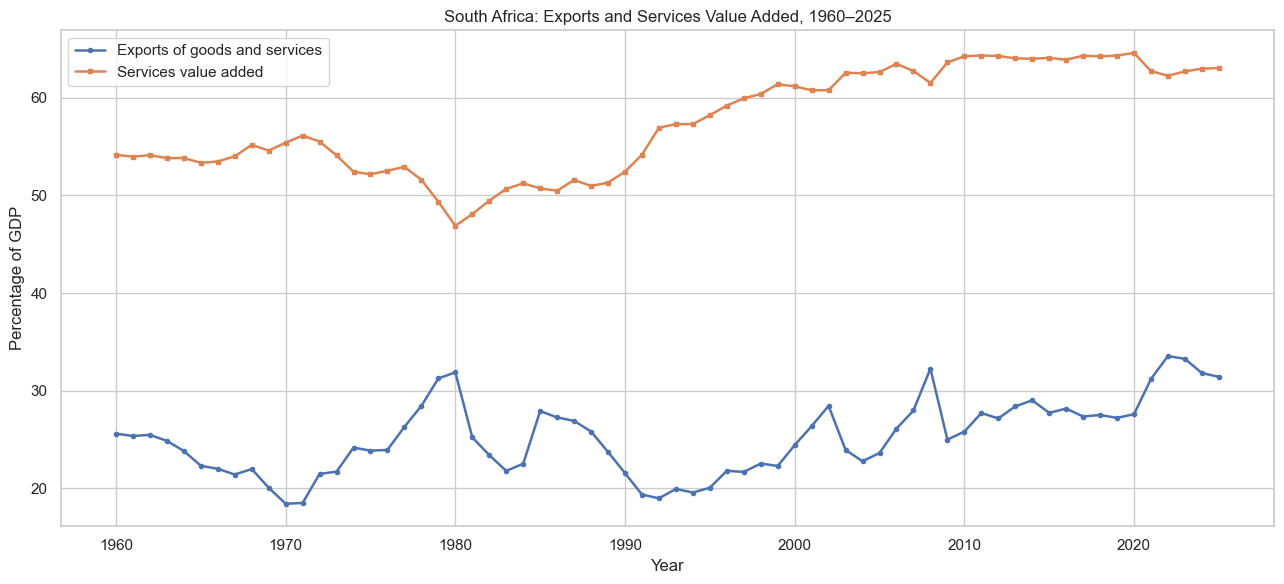

In [16]:
# Visualisation 1: long-run trajectories of both indicators.
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(comparison["Year"], comparison["Exports_Pct_GDP"], marker="o", markersize=3, linewidth=1.8, label="Exports of goods and services")
ax.plot(comparison["Year"], comparison["Services_Pct_GDP"], marker="s", markersize=3, linewidth=1.8, label="Services value added")
ax.set_title("South Africa: Exports and Services Value Added, 1960–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of GDP")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_long_run_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

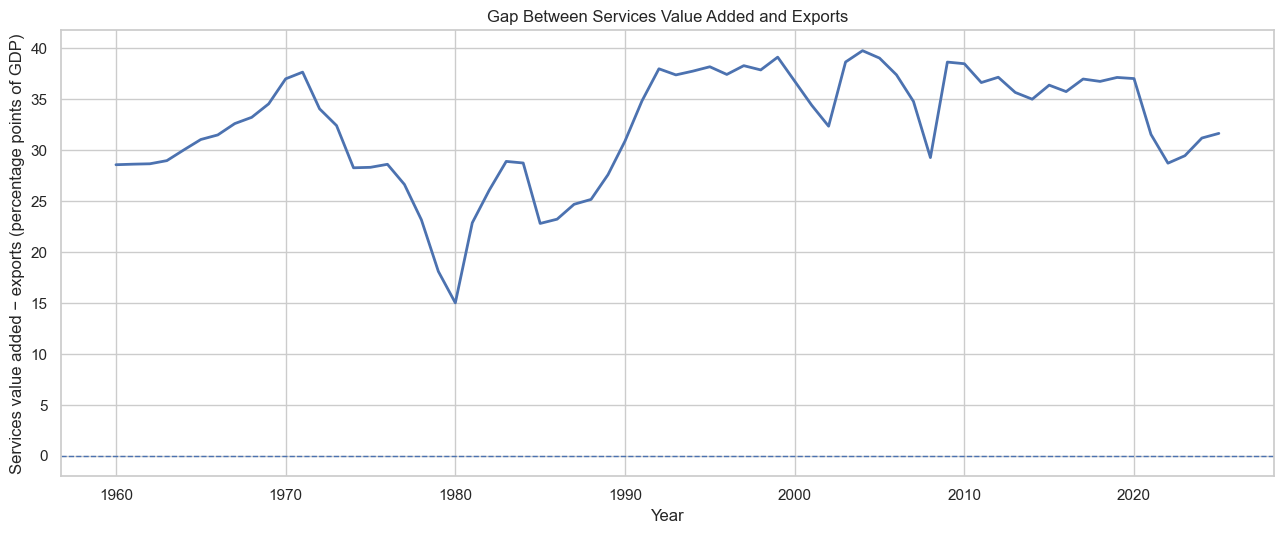

In [17]:
# Visualisation 2: services-minus-exports gap over time.
comparison["Gap_Services_minus_Exports"] = comparison["Services_Pct_GDP"] - comparison["Exports_Pct_GDP"]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(comparison["Year"], comparison["Gap_Services_minus_Exports"], linewidth=2)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Gap Between Services Value Added and Exports")
ax.set_xlabel("Year")
ax.set_ylabel("Services value added − exports (percentage points of GDP)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_services_exports_gap.png", dpi=300, bbox_inches="tight")
plt.show()

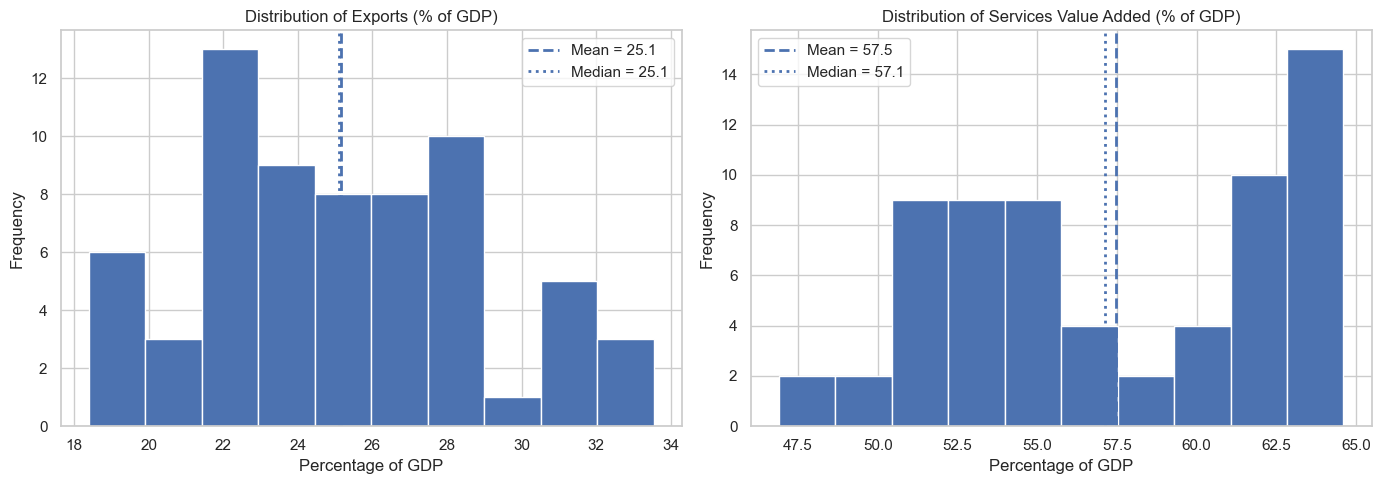

In [18]:
# Visualisation 3: distributions using histograms.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(exports_array, bins=10, edgecolor="white")
axes[0].axvline(np.mean(exports_array), linestyle="--", linewidth=2, label=f"Mean = {np.mean(exports_array):.1f}")
axes[0].axvline(np.median(exports_array), linestyle=":", linewidth=2, label=f"Median = {np.median(exports_array):.1f}")
axes[0].set_title("Distribution of Exports (% of GDP)")
axes[0].set_xlabel("Percentage of GDP")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(services_array, bins=10, edgecolor="white")
axes[1].axvline(np.mean(services_array), linestyle="--", linewidth=2, label=f"Mean = {np.mean(services_array):.1f}")
axes[1].axvline(np.median(services_array), linestyle=":", linewidth=2, label=f"Median = {np.median(services_array):.1f}")
axes[1].set_title("Distribution of Services Value Added (% of GDP)")
axes[1].set_xlabel("Percentage of GDP")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

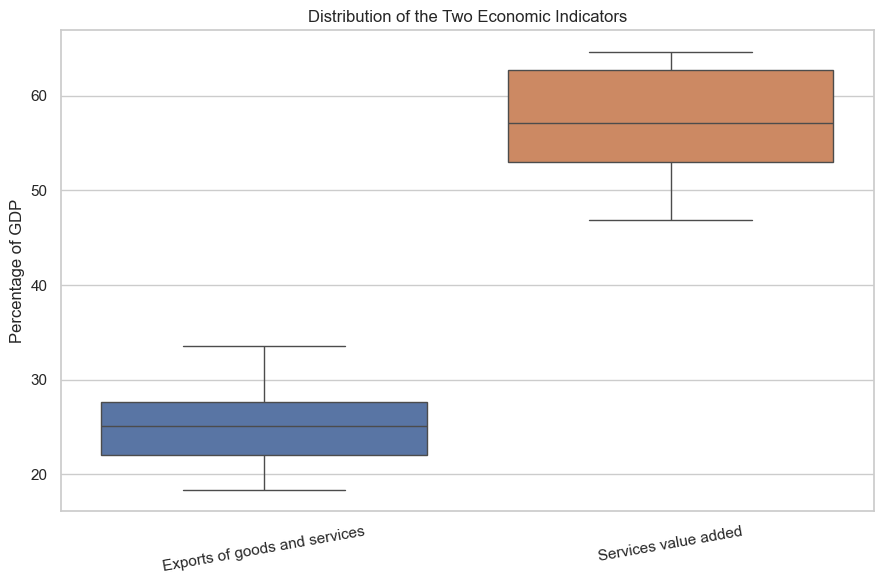

In [19]:
# Visualisation 4: box plot for side-by-side distribution comparison.
plot_df = comparison[["Exports_Pct_GDP", "Services_Pct_GDP"]].rename(columns={
    "Exports_Pct_GDP": "Exports of goods and services",
    "Services_Pct_GDP": "Services value added"
})

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=plot_df, ax=ax)
ax.set_title("Distribution of the Two Economic Indicators")
ax.set_ylabel("Percentage of GDP")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

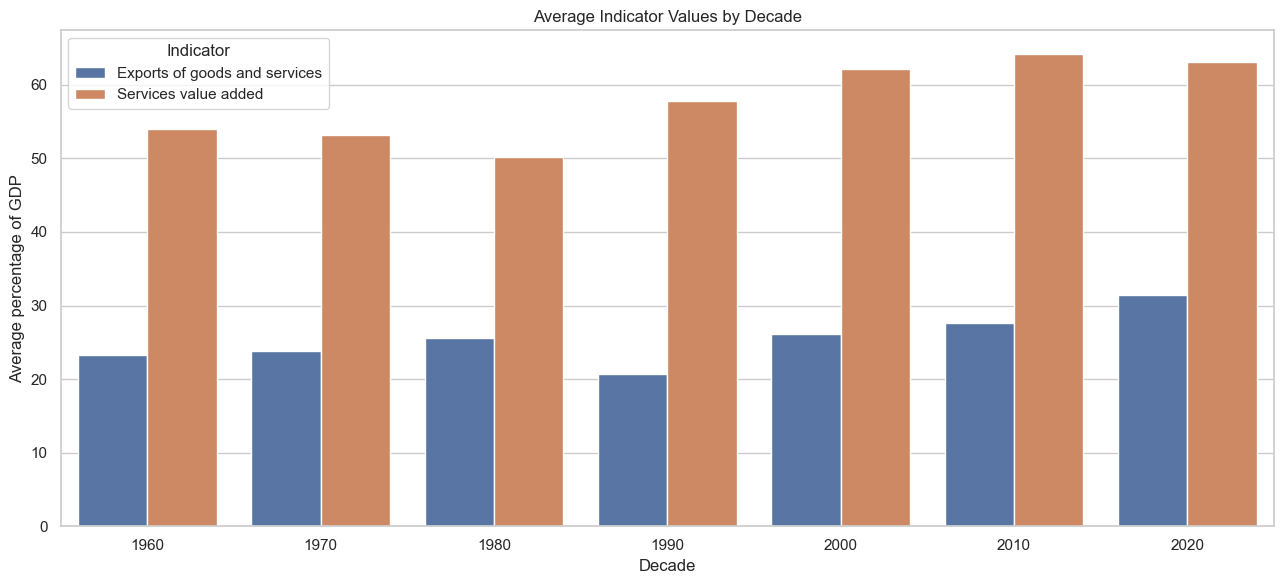

In [36]:
# Visualisation 5: decade averages.
decade_plot = decade_summary.copy()
long_decade = decade_plot.melt(
    id_vars="Decade",
    value_vars=["Exports_Mean", "Services_Mean"],
    var_name="Indicator",
    value_name="Average"
)
long_decade["Indicator"] = long_decade["Indicator"].map({
    "Exports_Mean": "Exports of goods and services",
    "Services_Mean": "Services value added"
})

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=long_decade, x="Decade", y="Average", hue="Indicator", ax=ax)
ax.set_title("Average Indicator Values by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Average percentage of GDP")
ax.legend(title="Indicator")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_decade_averages.png", dpi=300, bbox_inches="tight")
plt.show()

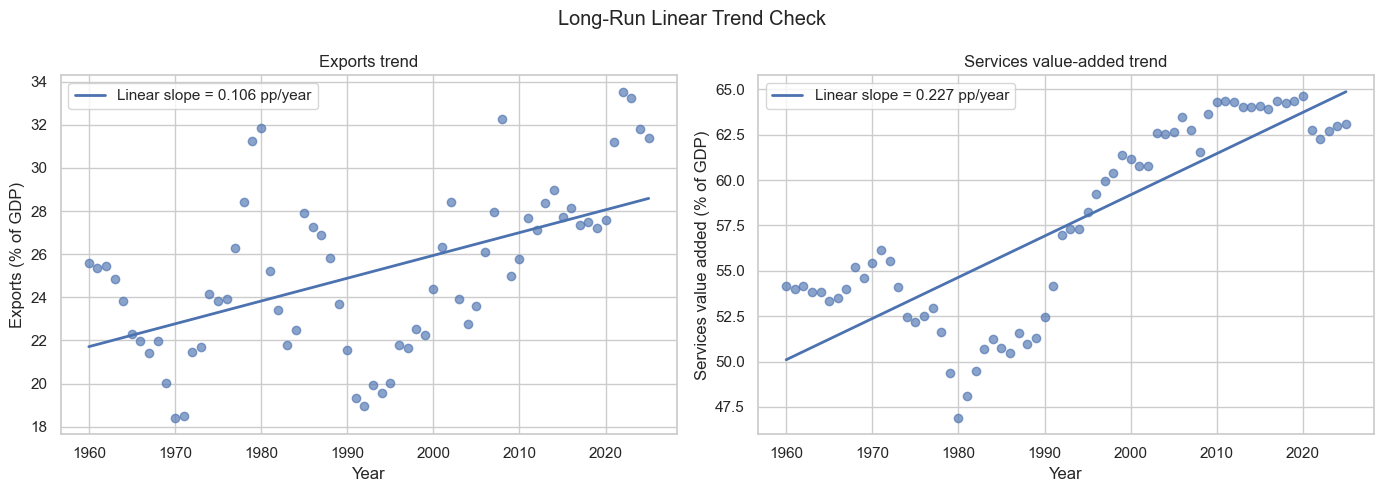

In [21]:
# Visualisation 6: time-trend scatter plots with fitted linear trends.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y, title, ylabel in [
    (axes[0], comparison["Exports_Pct_GDP"], "Exports trend", "Exports (% of GDP)"),
    (axes[1], comparison["Services_Pct_GDP"], "Services value-added trend", "Services value added (% of GDP)")
]:
    ax.scatter(comparison["Year"], y, alpha=0.65)
    slope, intercept = np.polyfit(comparison["Year"], y, 1)
    trend = slope * comparison["Year"] + intercept
    ax.plot(comparison["Year"], trend, linewidth=2, label=f"Linear slope = {slope:.3f} pp/year")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle("Long-Run Linear Trend Check")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_trend_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualisation Insights

The charts should be read together. The first chart answers where the two series moved; the gap chart answers whether their relationship changed; the histograms and box plot answer how concentrated or dispersed the historical observations are; and the decade chart prevents individual extreme years from dominating the story.

A particularly important interpretation is that the two series should not be added together and treated as components that must equal 100% of GDP. Exports of goods and services are a trade-flow measure, whereas services value added is a production/value-added measure; they can overlap conceptually and are not mutually exclusive components. The meaningful comparison is therefore relative scale, trend, volatility, and gap—not a claim that the two percentages form a complete GDP decomposition.

In [23]:
# Automated, data-specific visualisation findings.
peak_exports = comparison.loc[comparison["Exports_Pct_GDP"].idxmax()]
peak_services = comparison.loc[comparison["Services_Pct_GDP"].idxmax()]
low_exports = comparison.loc[comparison["Exports_Pct_GDP"].idxmin()]
low_services = comparison.loc[comparison["Services_Pct_GDP"].idxmin()]

print("VISUALISATION FINDINGS")
print(f"• Exports peak: {peak_exports['Exports_Pct_GDP']:.2f}% of GDP in {int(peak_exports['Year'])}.")
print(f"• Exports low: {low_exports['Exports_Pct_GDP']:.2f}% of GDP in {int(low_exports['Year'])}.")
print(f"• Services value added peak: {peak_services['Services_Pct_GDP']:.2f}% of GDP in {int(peak_services['Year'])}.")
print(f"• Services value added low: {low_services['Services_Pct_GDP']:.2f}% of GDP in {int(low_services['Year'])}.")
print(f"• Average services-minus-exports gap: {comparison['Gap_Services_minus_Exports'].mean():.2f} percentage points of GDP.")

VISUALISATION FINDINGS
• Exports peak: 33.54% of GDP in 2022.
• Exports low: 18.40% of GDP in 1970.
• Services value added peak: 64.61% of GDP in 2020.
• Services value added low: 46.89% of GDP in 1980.
• Average services-minus-exports gap: 32.33 percentage points of GDP.


####

In [24]:
# Creating a SQLite database.
db_path = OUTPUT_DIR / "south_africa_economic_analysis.db"
conn = sqlite3.connect(db_path)

print(f"SQLite database connected: {db_path}")

SQLite database connected: south_africa_analysis_outputs\south_africa_economic_analysis.db


In [25]:
# Storing the two cleaned source datasets in SQLite.
exports_analysis.to_sql("exports_data", conn, if_exists="replace", index=False)
services_analysis.to_sql("services_value_added", conn, if_exists="replace", index=False)
comparison.to_sql("integrated_data", conn, if_exists="replace", index=False)

print("Tables created: exports_data, services_value_added, integrated_data")

Tables created: exports_data, services_value_added, integrated_data


In [26]:
# Inspecting database schema and table inventory.
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn
)

display(tables)

display(pd.read_sql_query("PRAGMA table_info(integrated_data);", conn))

,name
0,exports_data
1,integrated_data
2,services_value_added


,cid,name,type,notnull,dflt_value,pk
0,0,Country_Code,TEXT,0,None,0
1,1,Country,TEXT,0,None,0
2,2,Year,INTEGER,0,None,0
3,3,Exports_Pct_GDP,REAL,0,None,0
4,4,Services_Pct_GDP,REAL,0,None,0
5,5,Decade,INTEGER,0,None,0
6,6,Gap_Services_minus_Exports,REAL,0,None,0


In [27]:
# SQL query: retrieving the latest five years and calculating a compact summary.
latest_five_sql = """
SELECT Year,
       ROUND(Exports_Pct_GDP, 2) AS Exports_Pct_GDP,
       ROUND(Services_Pct_GDP, 2) AS Services_Pct_GDP,
       ROUND(Gap_Services_minus_Exports, 2) AS Gap
FROM integrated_data
ORDER BY Year DESC
LIMIT 5;
"""

display(pd.read_sql_query(latest_five_sql, conn))

summary_sql = """
SELECT COUNT(*) AS Number_of_Years,
       ROUND(AVG(Exports_Pct_GDP), 2) AS Average_Exports,
       ROUND(AVG(Services_Pct_GDP), 2) AS Average_Services,
       ROUND(MIN(Exports_Pct_GDP), 2) AS Minimum_Exports,
       ROUND(MAX(Exports_Pct_GDP), 2) AS Maximum_Exports,
       ROUND(MIN(Services_Pct_GDP), 2) AS Minimum_Services,
       ROUND(MAX(Services_Pct_GDP), 2) AS Maximum_Services
FROM integrated_data;
"""

display(pd.read_sql_query(summary_sql, conn))

,Year,Exports_Pct_GDP,Services_Pct_GDP,Gap
0,2025,31.41,63.07,31.66
1,2024,31.79,62.99,31.20
2,2023,33.25,62.72,29.47
3,2022,33.54,62.27,28.73
4,2021,31.19,62.74,31.55


,Number_of_Years,Average_Exports,Average_Services,Minimum_Exports,Maximum_Exports,Minimum_Services,Maximum_Services
0,66,25.15,57.48,18.40,33.54,46.89,64.61


In [28]:
# Demonstrating safe UPDATE and DELETE operations on a temporary copy.
conn.execute("DROP TABLE IF EXISTS update_delete_test")
conn.execute("CREATE TABLE update_delete_test AS SELECT * FROM integrated_data")
conn.commit()

before_update = pd.read_sql_query(
    "SELECT Year, Exports_Pct_GDP FROM update_delete_test ORDER BY Year LIMIT 1;", conn
)
display(before_update)

# Safe update: targeting one specific record by its primary analytical key (Year).
first_year_value = int(comparison["Year"].min())
conn.execute(
    "UPDATE update_delete_test SET Exports_Pct_GDP = Exports_Pct_GDP WHERE Year = ?;",
    (first_year_value,)
)
conn.commit()

print("UPDATE executed safely using a parameterised Year condition.")

after_update = pd.read_sql_query(
    "SELECT Year, Exports_Pct_GDP FROM update_delete_test WHERE Year = ?;",
    conn, params=(first_year_value,)
)
display(after_update)

before_delete_count = pd.read_sql_query("SELECT COUNT(*) AS Records FROM update_delete_test;", conn).iloc[0, 0]
conn.execute("DELETE FROM update_delete_test WHERE Year = ?;", (first_year_value,))
conn.commit()
after_delete_count = pd.read_sql_query("SELECT COUNT(*) AS Records FROM update_delete_test;", conn).iloc[0, 0]

print(f"Records before DELETE: {before_delete_count}")
print(f"Records after DELETE: {after_delete_count}")
print("DELETE executed safely on the temporary test table; integrated_data remains unchanged.")

,Year,Exports_Pct_GDP
0,1960,25.59


UPDATE executed safely using a parameterised Year condition.


,Year,Exports_Pct_GDP
0,1960,25.59


Records before DELETE: 66
Records after DELETE: 65
DELETE executed safely on the temporary test table; integrated_data remains unchanged.


In [29]:
# Loading the database result back into Pandas.
final_data = pd.read_sql_query(
    "SELECT * FROM integrated_data ORDER BY Year;", conn
)

print(f"Database -> Pandas rows: {len(final_data)}")
print(f"Database -> Pandas columns: {len(final_data.columns)}")
display(final_data.head())

# Exporting the database result as CSV for evidence/reuse.
final_data.to_csv(OUTPUT_DIR / "integrated_data_from_database.csv", index=False)
print("CSV export completed.")

Database -> Pandas rows: 66
Database -> Pandas columns: 7


,Country_Code,Country,Year,Exports_Pct_GDP,Services_Pct_GDP,Decade,Gap_Services_minus_Exports
0,ZAF,South Africa,1960,25.59,54.17,1960,28.58
1,ZAF,South Africa,1961,25.34,53.98,1960,28.63
2,ZAF,South Africa,1962,25.46,54.14,1960,28.67
3,ZAF,South Africa,1963,24.84,53.82,1960,28.98
4,ZAF,South Africa,1964,23.81,53.84,1960,30.04


CSV export completed.


### Database Insight

The database stage adds reproducibility rather than simply satisfying a technical requirement. The integrated table becomes a single source of truth for later queries: the same year-level observations used in the statistical analysis can be retrieved with SQL and then returned to Pandas without rebuilding the integration manually. The update/delete demonstration is deliberately performed on a temporary copy so that the analytical source table is protected from destructive testing.

####

In [30]:
# Creating the final analysis table for Excel.
excel_analysis = comparison.copy()
excel_analysis["Average_of_Two_Indicators"] = (
    excel_analysis["Exports_Pct_GDP"] + excel_analysis["Services_Pct_GDP"]
) / 2
excel_analysis["Exports_5Y_Rolling_Mean"] = excel_analysis["Exports_Pct_GDP"].rolling(5, min_periods=1).mean()
excel_analysis["Services_5Y_Rolling_Mean"] = excel_analysis["Services_Pct_GDP"].rolling(5, min_periods=1).mean()
excel_analysis["Decade"] = (excel_analysis["Year"] // 10) * 10

# Ranking the size of the services-minus-exports gap.
excel_analysis["Gap_Rank"] = excel_analysis["Gap_Services_minus_Exports"].rank(method="min", ascending=False).astype(int)

display(excel_analysis.head(10).round(2))

,Country_Code,Country,Year,Exports_Pct_GDP,Services_Pct_GDP,Decade,Gap_Services_minus_Exports,Average_of_Two_Indicators,Exports_5Y_Rolling_Mean,Services_5Y_Rolling_Mean,Gap_Rank
0,ZAF,South Africa,1960,25.59,54.17,1960,28.58,39.88,25.59,54.17,53
1,ZAF,South Africa,1961,25.34,53.98,1960,28.63,39.66,25.46,54.07,51
2,ZAF,South Africa,1962,25.46,54.14,1960,28.67,39.80,25.46,54.09,50
3,ZAF,South Africa,1963,24.84,53.82,1960,28.98,39.33,25.31,54.03,46
4,ZAF,South Africa,1964,23.81,53.84,1960,30.04,38.82,25.01,53.99,43
5,ZAF,South Africa,1965,22.29,53.35,1960,31.06,37.82,24.35,53.83,41
6,ZAF,South Africa,1966,21.98,53.48,1960,31.50,37.73,23.68,53.73,39
7,ZAF,South Africa,1967,21.40,54.01,1960,32.62,37.70,22.86,53.70,34
8,ZAF,South Africa,1968,21.96,55.19,1960,33.23,38.58,22.29,53.98,33
9,ZAF,South Africa,1969,20.04,54.60,1960,34.55,37.32,21.53,54.13,30


In [31]:
# Excel workbook creation with formatting, conditional formatting and charts.
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.formatting.rule import ColorScaleRule, CellIsRule
from openpyxl.chart import LineChart, BarChart, Reference
from openpyxl.utils import get_column_letter

excel_file = OUTPUT_DIR / "South_Africa_Economic_Analysis.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    excel_analysis.to_excel(writer, sheet_name="Combined Analysis", index=False)
    descriptive_stats.round(2).to_excel(writer, sheet_name="Descriptive Statistics")
    decade_summary.round(2).to_excel(writer, sheet_name="Decade Summary", index=False)
    change_summary.round(2).to_excel(writer, sheet_name="Period Change", index=False)

wb = load_workbook(excel_file)
ws = wb["Combined Analysis"]

# Header formatting and usability.
for cell in ws[1]:
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center")
ws.freeze_panes = "A2"
ws.auto_filter.ref = ws.dimensions

# Conditional formatting for the two main indicators and the gap.
headers = {cell.value: cell.column for cell in ws[1]}
for col_name in ["Exports_Pct_GDP", "Services_Pct_GDP", "Gap_Services_minus_Exports"]:
    col = get_column_letter(headers[col_name])
    ws.conditional_formatting.add(
        f"{col}2:{col}{ws.max_row}",
        ColorScaleRule(start_type="min", start_color="F8696B",
                       mid_type="percentile", mid_value=50, mid_color="FFEB84",
                       end_type="max", end_color="63BE7B")
    )

# Adding a line chart showing both indicators.
line_chart = LineChart()
line_chart.title = "South Africa: Exports and Services Value Added"
line_chart.y_axis.title = "Percentage of GDP"
line_chart.x_axis.title = "Year"
line_chart.height = 8
line_chart.width = 16

year_col = headers["Year"]
exp_col = headers["Exports_Pct_GDP"]
svc_col = headers["Services_Pct_GDP"]

data = Reference(ws, min_col=exp_col, max_col=svc_col, min_row=1, max_row=ws.max_row)
cats = Reference(ws, min_col=year_col, min_row=2, max_row=ws.max_row)
line_chart.add_data(data, titles_from_data=True)
line_chart.set_categories(cats)
ws.add_chart(line_chart, "N2")

# Adding a bar chart for decade averages.
ws_dec = wb["Decade Summary"]
bar_chart = BarChart()
bar_chart.title = "Average Indicators by Decade"
bar_chart.y_axis.title = "Percentage of GDP"
bar_chart.x_axis.title = "Decade"
bar_chart.height = 8
bar_chart.width = 16
bar_data = Reference(ws_dec, min_col=2, max_col=3, min_row=1, max_row=ws_dec.max_row)
bar_cats = Reference(ws_dec, min_col=1, min_row=2, max_row=ws_dec.max_row)
bar_chart.add_data(bar_data, titles_from_data=True)
bar_chart.set_categories(bar_cats)
ws_dec.add_chart(bar_chart, "F2")

# Reasonable column widths.
for sheet in wb.worksheets:
    for column_cells in sheet.columns:
        max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
        sheet.column_dimensions[get_column_letter(column_cells[0].column)].width = min(max(max_len + 2, 12), 32)

wb.save(excel_file)
print(f"Excel workbook created: {excel_file}")

Excel workbook created: south_africa_analysis_outputs\South_Africa_Economic_Analysis.xlsx


In [32]:
# Verifying the workbook and its required sheets.
wb_check = load_workbook(excel_file, read_only=True)
print("Workbook sheets:", wb_check.sheetnames)
assert "Combined Analysis" in wb_check.sheetnames
assert "Descriptive Statistics" in wb_check.sheetnames
assert "Decade Summary" in wb_check.sheetnames
assert "Period Change" in wb_check.sheetnames
print("Excel verification passed.")

Workbook sheets: ['Combined Analysis', 'Descriptive Statistics', 'Decade Summary', 'Period Change']
Excel verification passed.


### Python/Excel Insight

The Excel output is more than a data dump. The gap column identifies the years in which services value added was furthest above exports, while the rolling means reduce the influence of single-year fluctuations and make longer-term movement easier to see. Conditional formatting then allows a reviewer to locate high and low observations without reading every row.

In [37]:
# Final findings block.
print("FINAL SOUTH AFRICA ECONOMIC ANALYSIS FINDINGS")
print(f"Analysis period: {int(comparison['Year'].min())}–{int(comparison['Year'].max())}")
print(f"Average exports: {comparison['Exports_Pct_GDP'].mean():.2f}% of GDP")
print(f"Average services value added: {comparison['Services_Pct_GDP'].mean():.2f}% of GDP")
print(f"Average services-minus-exports gap: {comparison['Gap_Services_minus_Exports'].mean():.2f} percentage points")
print(f"Exports coefficient of variation: {exports_cv:.2f}%")
print(f"Services coefficient of variation: {services_cv:.2f}%")
print(f"Correlation: {correlation:.3f}")
print(f"Exports peak: {peak_exports['Exports_Pct_GDP']:.2f}% in {int(peak_exports['Year'])}")
print(f"Services value-added peak: {peak_services['Services_Pct_GDP']:.2f}% in {int(peak_services['Year'])}")
print(f"Latest-year gap ({int(last_year)}): {latest_gap:.2f} percentage points")
print(f"Outputs saved to: {OUTPUT_DIR.resolve()}")

FINAL SOUTH AFRICA ECONOMIC ANALYSIS FINDINGS
Analysis period: 1960–2025
Average exports: 25.15% of GDP
Average services value added: 57.48% of GDP
Average services-minus-exports gap: 32.33 percentage points
Exports coefficient of variation: 15.14%
Services coefficient of variation: 9.26%
Correlation: 0.301
Exports peak: 33.54% in 2022
Services value-added peak: 64.61% in 2020
Latest-year gap (2025): 31.66 percentage points
Outputs saved to: C:\Users\Admin\OneDrive - Sol Plaatje University\Desktop\DATA ANALYSIS AND VISUALIZATION NDTA631\NDTA631-South-Africa-Trade-Services\south_africa_analysis_outputs


In [34]:
# Closing the database connection after all SQL work is complete.
conn.close()
print("SQLite connection closed. Analysis pipeline complete.")

SQLite connection closed. Analysis pipeline complete.
